Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

Upload Dataset (IMPORTANT for Colab)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


Load Dataset


In [ ]:
df = pd.read_csv('netflix_titles.csv')

print(df.head())
print(df.shape)
print(df.dtypes)

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

Data Cleaning
Check missing values

In [ ]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


Fill missing categorical values

In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna('Unknown', inplace=True)

/tmp/ipykernel_2744/365260942.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


Fill numeric missing values

In [ ]:
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2744/2155874100.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Remove duplicates

In [ ]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicates before: 0


🔹 Statistics
Convert duration to numeric

In [ ]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2744/710516317.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


Calculate stats

In [ ]:
for col in ['release_year', 'duration_num']:
    print(f"\nStats for {col}:")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Std:", df[col].std())
    print("Variance:", df[col].var())
    print("Range:", df[col].max() - df[col].min())
    print("Mid-range:", (df[col].max() + df[col].min()) / 2)


Stats for release_year:
Mean: 2014.1801975701146
Median: 2017.0
Mode: 2018
Std: 8.819312130834057
Variance: 77.78026646107675
Range: 96
Mid-range: 1973.0

Stats for duration_num:
Mean: 69.84688777828259
Median: 88.0
Mode: 1.0
Std: 50.81482778918891
Variance: 2582.146723244926
Range: 311.0
Mid-range: 156.5


🔹 Visualization
Histogram

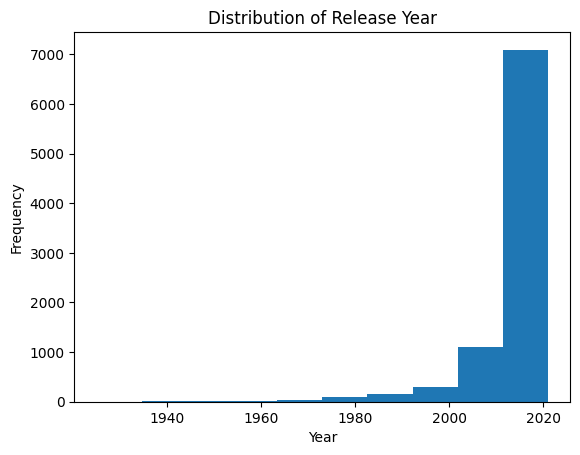

In [ ]:
plt.figure()
plt.hist(df['release_year'])
plt.title('Distribution of Release Year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

Bar Chart

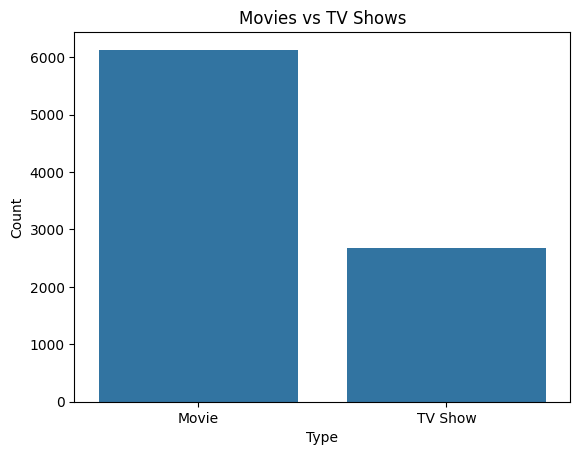

In [ ]:
plt.figure()
sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

Boxplot

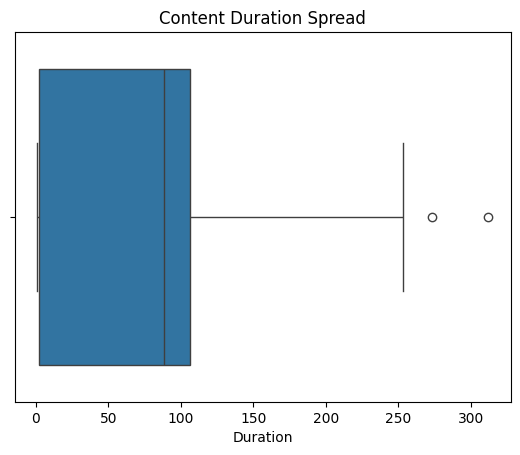

In [ ]:
plt.figure()
sns.boxplot(x=df['duration_num'])
plt.title('Content Duration Spread')
plt.xlabel('Duration')
plt.show()

Heatmap

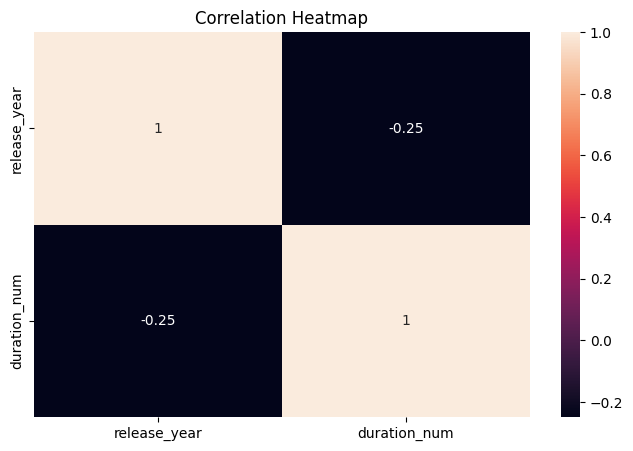

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

🔹 Encoding

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

🔹 Train-Test Split

In [ ]:
X = df.drop('type', axis=1)
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

🔹 Model

In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.9994324631101021


🔹 Insights (Markdown)

In [ ]:
"""
Finding 1: Most content on Netflix is movies rather than TV shows.
Finding 2: The histogram shows a sharp increase in content after 2010.
Finding 3: The boxplot shows some extreme duration outliers.

Recommendations:
1. Focus on producing more recent content as it dominates the platform.
2. Balance between movies and TV shows for better audience engagement.
"""

'\nFinding 1: Most content on Netflix is movies rather than TV shows.\nFinding 2: The histogram shows a sharp increase in content after 2010.\nFinding 3: The boxplot shows some extreme duration outliers.\n\nRecommendations:\n1. Focus on producing more recent content as it dominates the platform.\n2. Balance between movies and TV shows for better audience engagement.\n'